# Figure 1: Time-domain digital filtering of a noisy signal.

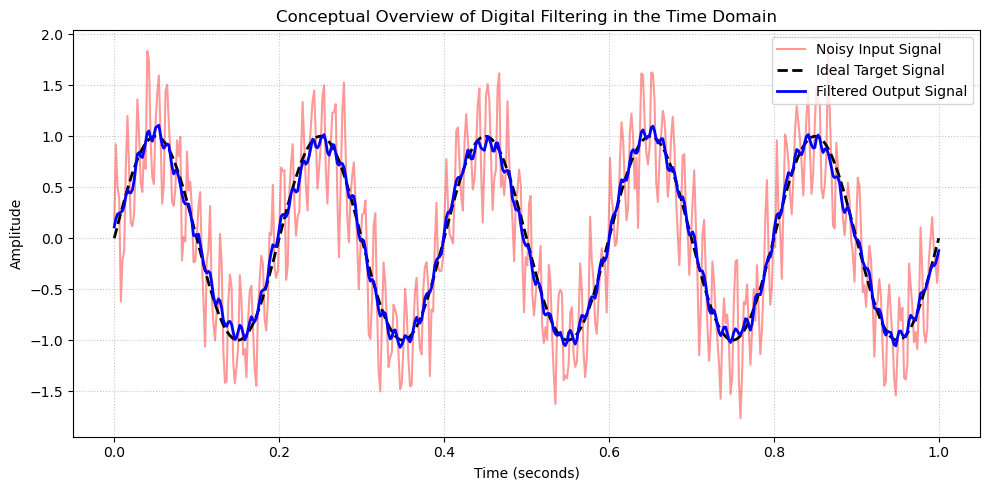

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a clean low-frequency signal combined with high-frequency noise
t = np.linspace(0, 1, 500)
clean_signal = np.sin(2 * np.pi * 5 * t)  # 5 Hz target signal
noise = 0.5 * np.sin(2 * np.pi * 80 * t) + 0.2 * np.random.normal(0, 1, 500)  # Noise component
noisy_signal = clean_signal + noise

# 2. Simple moving average filter to simulate generic smoothing (filtering)
window_size = 15
filtered_signal = np.convolve(noisy_signal, np.ones(window_size)/window_size, mode='same')

# 3. Plotting the conceptual overview
plt.figure(figsize=(10, 5))
plt.plot(t, noisy_signal, 'r', alpha=0.4, label='Noisy Input Signal')
plt.plot(t, clean_signal, 'k--', linewidth=2, label='Ideal Target Signal')
plt.plot(t, filtered_signal, 'b', linewidth=2, label='Filtered Output Signal')

plt.title('Conceptual Overview of Digital Filtering in the Time Domain')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Save the figure for the Introduction section in LaTeX
plt.tight_layout()
plt.savefig('generic_filtering_demo.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Ideal vs. truncated FIR low-pass filter.

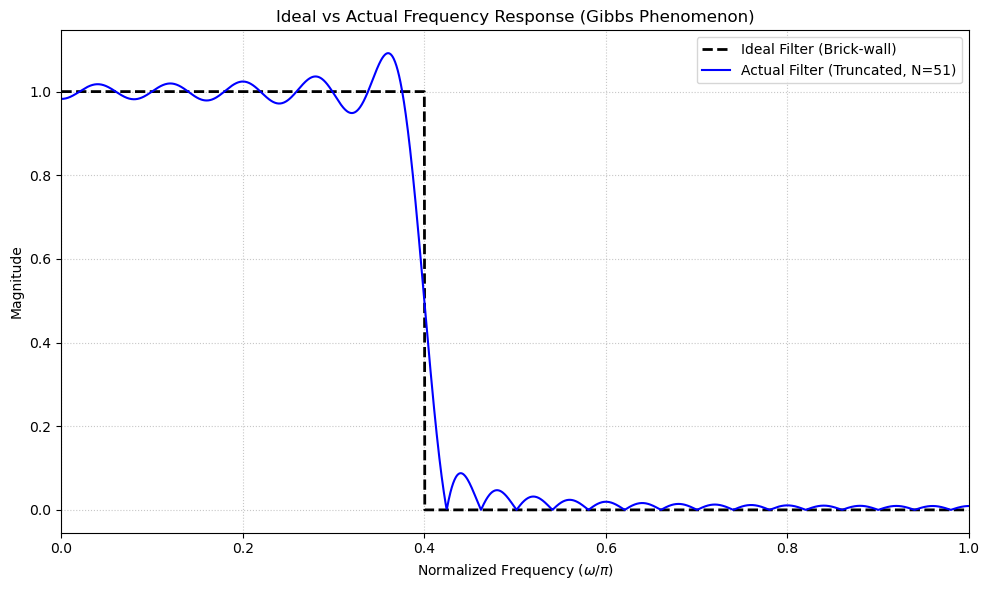

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# 1. Define filter parameters
fc = 0.2  # Normalized cutoff frequency (fraction of Nyquist)
M = 25    # Half-length of the filter
N = 2 * M + 1
n = np.arange(-M, M + 1)

# 2. Generate ideal impulse response (sinc function)
# Initialize array and handle the division by zero at n=0
h_ideal = np.zeros(N)
h_ideal[n == 0] = 2 * fc
h_ideal[n != 0] = np.sin(2 * np.pi * fc * n[n != 0]) / (np.pi * n[n != 0])

# 3. Calculate frequency response of the truncated filter
w, H_actual = signal.freqz(h_ideal, worN=2048)
w_norm = w / np.pi  # Normalize frequency axis (0 to 1, where 1 is Nyquist)

# 4. Create the ideal frequency response (brick-wall) for comparison
# Magnitude is 1 up to the cutoff frequency, and 0 afterwards
H_ideal_freq = np.where(w_norm <= 2 * fc, 1.0, 0.0)

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(w_norm, H_ideal_freq, 'k--', linewidth=2, label='Ideal Filter (Brick-wall)')
plt.plot(w_norm, np.abs(H_actual), 'b', linewidth=1.5, label=f'Actual Filter (Truncated, N={N})')

plt.title('Ideal vs Actual Frequency Response (Gibbs Phenomenon)')
plt.xlabel('Normalized Frequency ($\omega / \pi$)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 1)

# 6. Save the figure in high resolution for LaTeX
plt.tight_layout()
plt.savefig('FIR_ideal_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: The Gibbs phenomenon for different filter lengths.

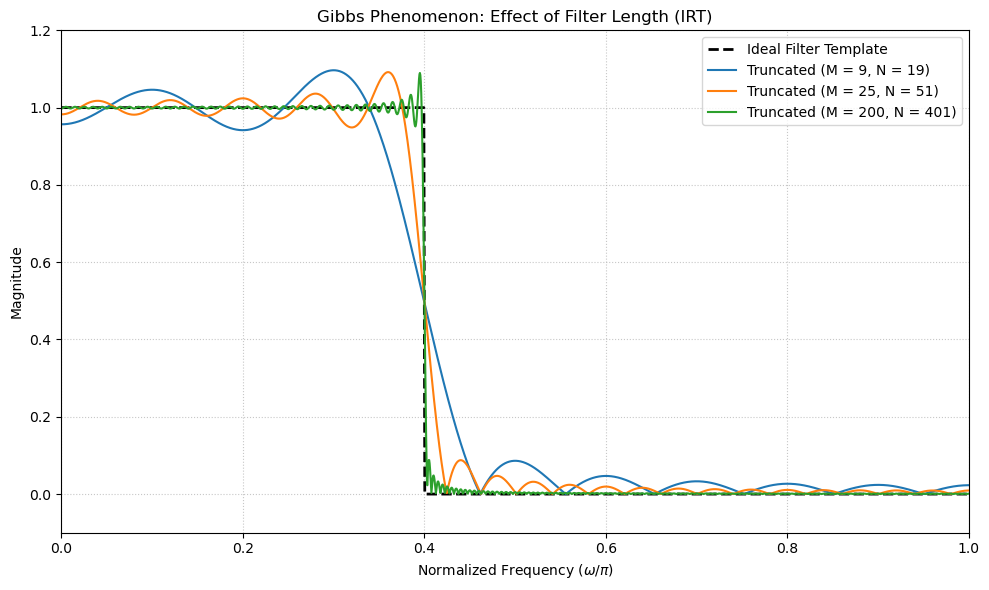

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# 1. Define filter parameters
fc = 0.2  # Normalized cutoff frequency
M_values = [9, 25, 200]  # Different M values to demonstrate the Gibbs phenomenon

plt.figure(figsize=(10, 6))

# 2. Plot the ideal brick-wall filter template
w_ideal = np.linspace(0, 1, 1000)
H_ideal = np.where(w_ideal <= 2 * fc, 1.0, 0.0)
plt.plot(w_ideal, H_ideal, 'k--', linewidth=2, label='Ideal Filter Template')

# 3. Compute and plot the response for each M value
for M in M_values:
    N = 2 * M + 1
    n = np.arange(-M, M + 1)
    
    # Sinc impulse response calculation
    h = np.zeros(N)
    h[n == 0] = 2 * fc
    h[n != 0] = np.sin(2 * np.pi * fc * n[n != 0]) / (np.pi * n[n != 0])
    
    # Frequency response calculation
    w, H = signal.freqz(h, worN=2048)
    plt.plot(w / np.pi, np.abs(H), linewidth=1.5, label=f'Truncated (M = {M}, N = {N})')

plt.title('Gibbs Phenomenon: Effect of Filter Length (IRT)')
plt.xlabel('Normalized Frequency ($\omega / \pi$)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 1)
plt.ylim(-0.1, 1.2)

# 4. Save the figure for Section 3 in LaTeX
plt.tight_layout()
plt.savefig('gibbs_multi_m.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Standard window functions in time and frequency domains.

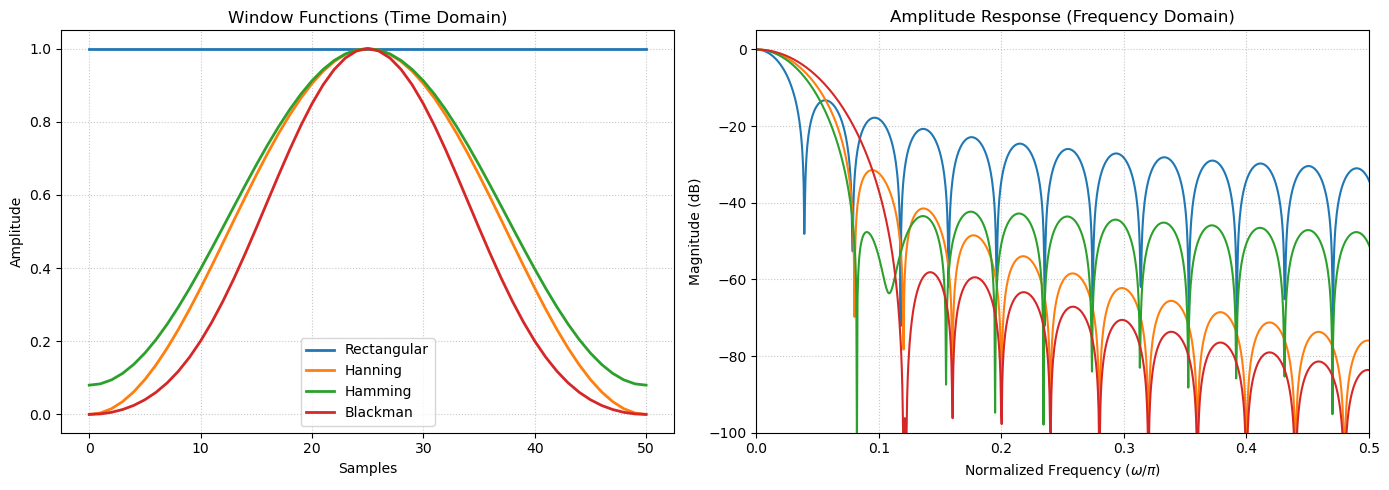

In [2]:
# 1. Define parameters
M = 25
N = 2 * M + 1

# 2. Generate standard window functions using numpy
win_rect = np.ones(N)
win_hanning = np.hanning(N)
win_hamming = np.hamming(N)
win_blackman = np.blackman(N)

# Group them for easy iteration
windows = [
    ('Rectangular', win_rect),
    ('Hanning', win_hanning),
    ('Hamming', win_hamming),
    ('Blackman', win_blackman)
]

# 3. Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 4. Iterate through windows to plot both time and frequency domains
for name, win in windows:
    # Time domain plot
    ax1.plot(win, label=name, linewidth=2)
    
    # Frequency domain plot (Spectrum of the window)
    w, H = signal.freqz(win, worN=2048)
    
    # Convert magnitude to Decibels (dB) and normalize to 0 dB peak
    # Add a small value (1e-10) to avoid log10(0) warning
    H_dB = 20 * np.log10(np.maximum(np.abs(H), 1e-10) / np.max(np.abs(H)))
    ax2.plot(w / np.pi, H_dB, label=name, linewidth=1.5)

# 5. Customize the Time Domain subplot (ax1)
ax1.set_title('Window Functions (Time Domain)')
ax1.set_xlabel('Samples')
ax1.set_ylabel('Amplitude')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# 6. Customize the Frequency Domain subplot (ax2)
ax2.set_title('Amplitude Response (Frequency Domain)')
ax2.set_xlabel('Normalized Frequency ($\omega / \pi$)')
ax2.set_ylabel('Magnitude (dB)')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_xlim(0, 0.5)  # Zoom in on the first half to clearly see the lobes
ax2.set_ylim(-100, 5)

# 7. Save the figure in high resolution for LaTeX
plt.tight_layout()
plt.savefig('window_functions.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: Effect of the continuous shape parameter β on a Kaiser window filter.

C:\Users\jorge\AppData\Local\Temp\ipykernel_14472\3564684713.py:13: RuntimeWarning: invalid value encountered in divide
  h_ideal = np.where(n == 0, wc_norm, np.sin(np.pi * wc_norm * n) / (np.pi * n))


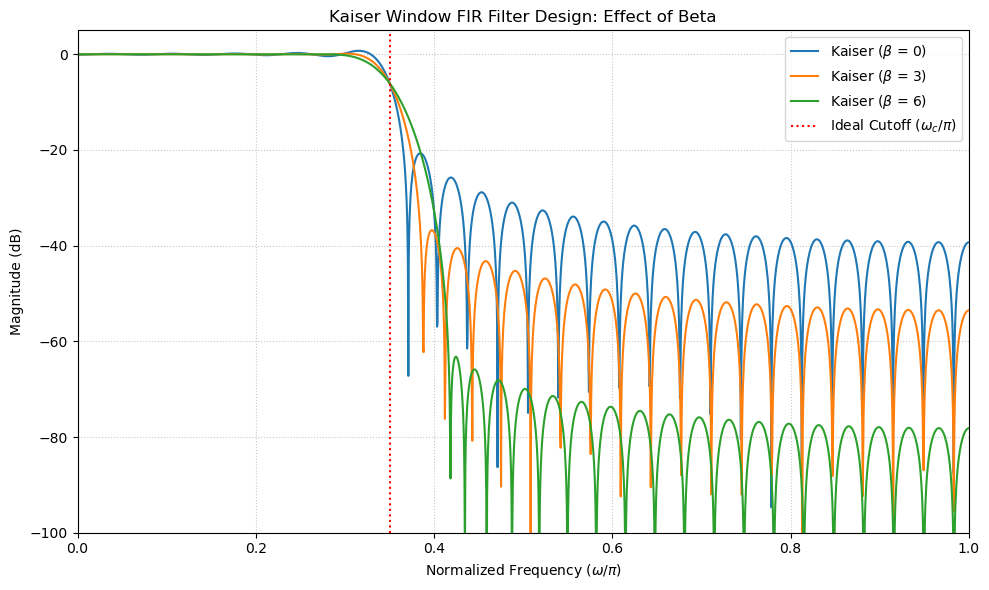

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# 1. Define filter parameters based on lecture notes
# wc = 0.35 * pi -> Normalized cutoff frequency is 0.35
wc_norm = 0.35  
M = 29     # Half-length of the filter (N = 61 coefficients)
N = 2 * M + 1
n = np.arange(-M, M + 1)

# 2. Calculate ideal impulse response (sinc function)
h_ideal = np.where(n == 0, wc_norm, np.sin(np.pi * wc_norm * n) / (np.pi * n))

# 3. Define beta shape parameters to evaluate
betas = [0, 3, 6]

# 4. Plotting the frequency responses
plt.figure(figsize=(10, 6))

for beta in betas:
    # Generate the Kaiser window for the current beta
    win_kaiser = np.kaiser(N, beta)
    
    # Apply the window to the ideal impulse response
    h_kaiser = h_ideal * win_kaiser
    
    # Compute the frequency response
    w, H = signal.freqz(h_kaiser, worN=2048)
    
    # Convert magnitude response to Decibels (dB)
    H_dB = 20 * np.log10(np.maximum(np.abs(H), 1e-10))
    plt.plot(w / np.pi, H_dB, linewidth=1.5, label=f'Kaiser ($\\beta$ = {beta})')

# 5. Customize plot layout
plt.title('Kaiser Window FIR Filter Design: Effect of Beta')
plt.xlabel('Normalized Frequency ($\omega / \pi$)')
plt.ylabel('Magnitude (dB)')
plt.axvline(x=wc_norm, color='r', linestyle=':', label='Ideal Cutoff ($\omega_c/\pi$)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 1)
plt.ylim(-100, 5)

# 6. Save the final figure for Section 5 in LaTeX
plt.tight_layout()
plt.savefig('kaiser_window_comparison.png', dpi=300, bbox_inches='tight')
plt.show()